In [7]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

from training_utils import (
    calculate_sparse_fingerprints,
    build_fingerprint_vocabulary,
    build_fingerprint_index,
    build_feature_matrix,
    calculate_base_features,
)

TRAIN_CSV = "../../train_data.csv"
TEST_CSV = "../../test_data.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"], # Standard crisp fonts
    "axes.linewidth": 1.5,               # Thicker axis lines
    "axes.spines.top": False,            # Remove top spine
    "axes.spines.right": False,          # Remove right spine
    "xtick.major.width": 1.5,            # Match tick thickness to axis
    "ytick.major.width": 1.5,
    "xtick.direction": "out",            # Ticks point outside
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

Train: 39665 rows | Test: 10369 rows


# PCA / UMAP breakdown of train vs. test chemical space (full feature space, fit on train only)

In [8]:
def build_shared_vocab(train_df, fp_min_count=40):
    fps = calculate_sparse_fingerprints(train_df["smi"])
    fp_vocab = build_fingerprint_vocabulary(fps, fp_min_count)
    fp_index = build_fingerprint_index(fp_vocab)
    adducts = sorted(train_df["adduct"].unique())
    return fp_index, adducts


def compute_full_features(df, fp_index, adducts):
    fps = calculate_sparse_fingerprints(df["smi"])
    base_features = [
        calculate_base_features(row["smi"], row["z"], adducts, row["adduct"])
        for _, row in df.iterrows()
    ]
    return build_feature_matrix(base_features, fps, fp_index)


NULL_COLOR = (0.0, 0.0, 0.0, 1.0)
NULL_LABEL = "NULL"
GROUND_TRUTH_MARKER = "o"
PREDICTED_MARKER = "^"


def strip_predicted_suffix(superclass_series):
    return superclass_series.str.replace(r" \(predicted\)$", "", regex=True)


def build_shared_category_palette(*superclass_series_list):
    categories = sorted(set().union(*[
        strip_predicted_suffix(s).dropna().unique() for s in superclass_series_list
    ]))
    palette = plt.cm.hsv(np.linspace(0, 1, len(categories), endpoint=False))
    category_to_color = dict(zip(categories, palette))
    category_to_color[NULL_LABEL] = NULL_COLOR
    return category_to_color


def plot_chemical_space(ax, coords, superclass_series, category_to_color, xlabel, ylabel, axis_min, axis_max, title=None):
    base_category = strip_predicted_suffix(superclass_series)
    is_predicted = superclass_series.str.endswith(" (predicted)").fillna(False).astype(bool).to_numpy()

    point_colors = np.array([
        category_to_color[val] if pd.notna(val) else NULL_COLOR
        for val in base_category
    ])

    ax.scatter(coords[~is_predicted, 0], coords[~is_predicted, 1],
               c=point_colors[~is_predicted], marker=GROUND_TRUTH_MARKER, s=8, alpha=0.6, edgecolors="none")
    ax.scatter(coords[is_predicted, 0], coords[is_predicted, 1],
               c=point_colors[is_predicted], marker=PREDICTED_MARKER, s=10, alpha=0.6, edgecolors="none")

    pad = (axis_max - axis_min) * 0.05
    ax.set_xlim(axis_min - pad, axis_max + pad)
    ax.set_ylim(axis_min - pad, axis_max + pad)
    ax.set_aspect("equal")

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc="left", fontweight="bold", pad=15)

    # roughly how many legend rows fit before running past the bottom of the
    # axes box, given the current font size -- wrap into more columns past that
    fontsize = 8
    fig_height_inches = ax.figure.get_size_inches()[1]
    row_height_inches = (fontsize / 72) * 1.8
    max_rows_per_col = max(1, int(fig_height_inches / row_height_inches))
    ncol = int(np.ceil(len(category_to_color) / max_rows_per_col))

    color_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=color,
               markeredgecolor="none", markersize=6, label=label)
        for label, color in category_to_color.items()
    ]
    color_legend = ax.legend(
        handles=color_handles,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        ncol=ncol,
        frameon=False,
        fontsize=fontsize,
        title="Superclass",
    )
    ax.add_artist(color_legend)

    shape_handles = [
        Line2D([0], [0], marker=GROUND_TRUTH_MARKER, linestyle="none", markerfacecolor="gray",
               markeredgecolor="none", markersize=6, label="Ground truth"),
        Line2D([0], [0], marker=PREDICTED_MARKER, linestyle="none", markerfacecolor="gray",
               markeredgecolor="none", markersize=6, label="Predicted"),
    ]
    ax.legend(
        handles=shape_handles,
        loc="lower left",
        bbox_to_anchor=(1.02, 0.0),
        frameon=False,
        fontsize=fontsize,
        title="Source",
    )

In [9]:
fp_index, adducts = build_shared_vocab(train_df, fp_min_count=40)

X_train_full = compute_full_features(train_df, fp_index, adducts)
X_test_full = compute_full_features(test_df, fp_index, adducts)

scaler = StandardScaler().fit(X_train_full)
X_train_scaled = scaler.transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

category_to_color = build_shared_category_palette(train_df["superclass"], test_df["superclass"])

print(f"Full feature space: {X_train_full.shape[1]} columns")
print(f"Superclass categories (incl. NULL): {len(category_to_color)}")

Full feature space: 3775 columns
Superclass categories (incl. NULL): 20


## PCA

/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:350: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/utils/extmath.py:351: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/a

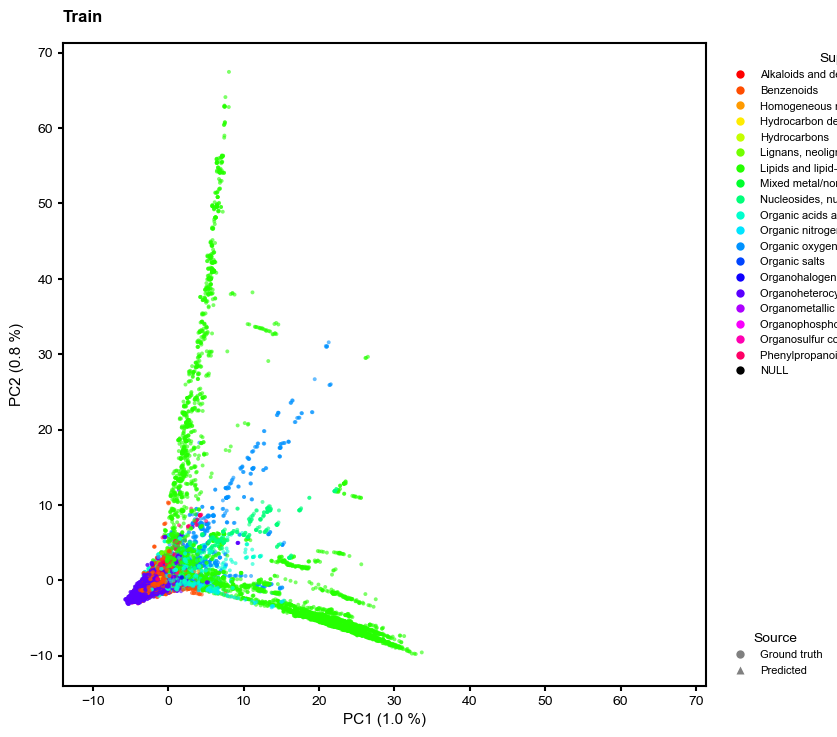

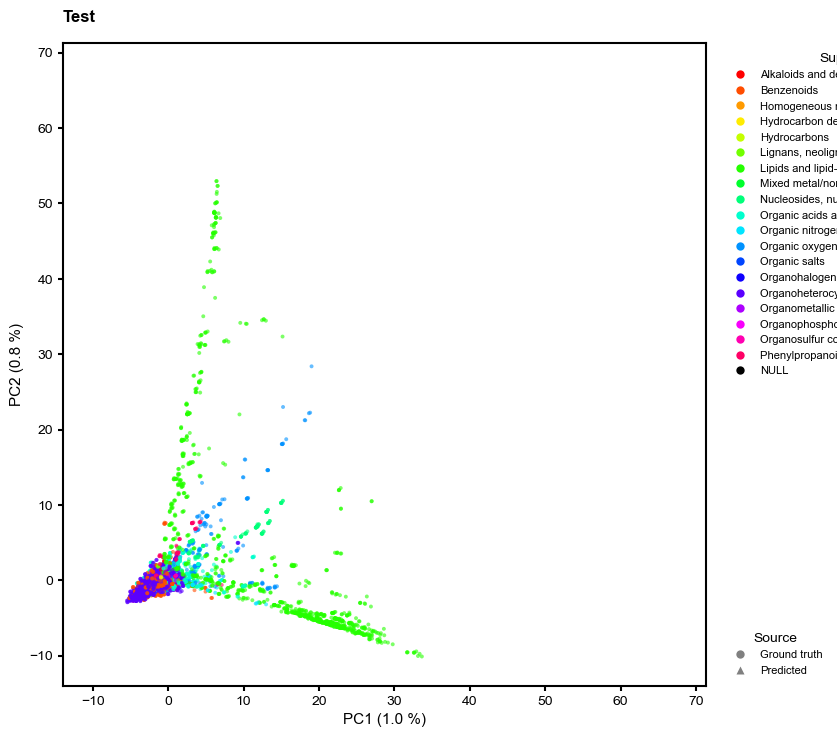

In [10]:
pca = PCA(n_components=2, random_state=26).fit(X_train_scaled)
Z_train = pca.transform(X_train_scaled)
Z_test = pca.transform(X_test_scaled)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
xlabel, ylabel = f"PC1 ({var1:.1f} %)", f"PC2 ({var2:.1f} %)"

axis_min = min(Z_train[:, 0].min(), Z_train[:, 1].min(), Z_test[:, 0].min(), Z_test[:, 1].min())
axis_max = max(Z_train[:, 0].max(), Z_train[:, 1].max(), Z_test[:, 0].max(), Z_test[:, 1].max())

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
plot_chemical_space(ax, Z_train, train_df["superclass"], category_to_color, xlabel, ylabel, axis_min, axis_max, title="Train")
plt.show()

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
plot_chemical_space(ax, Z_test, test_df["superclass"], category_to_color, xlabel, ylabel, axis_min, axis_max, title="Test")
plt.show()

## UMAP

/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/anaconda3/envs/ccsbase/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/opt/anacond

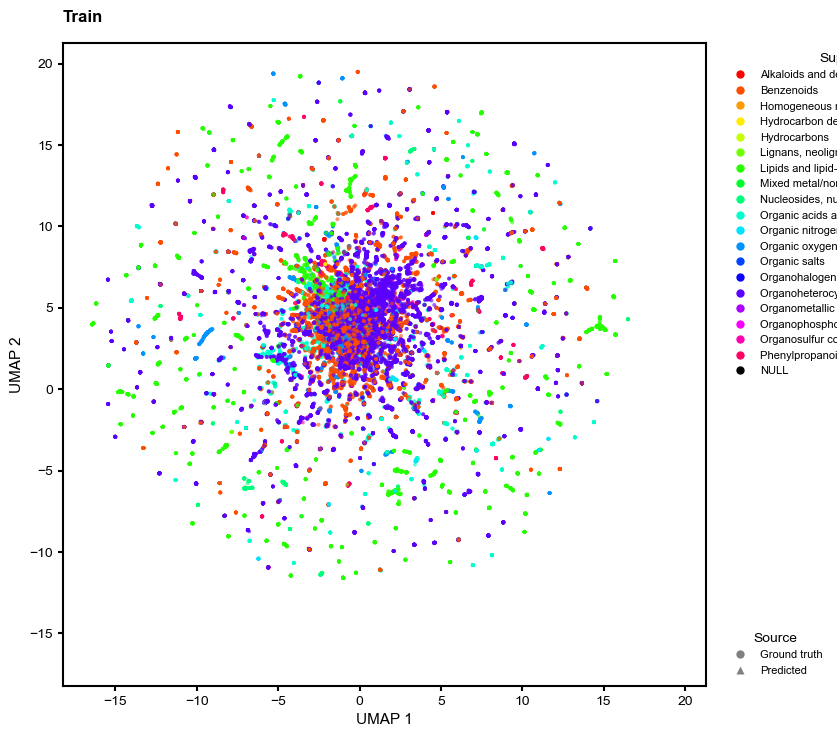

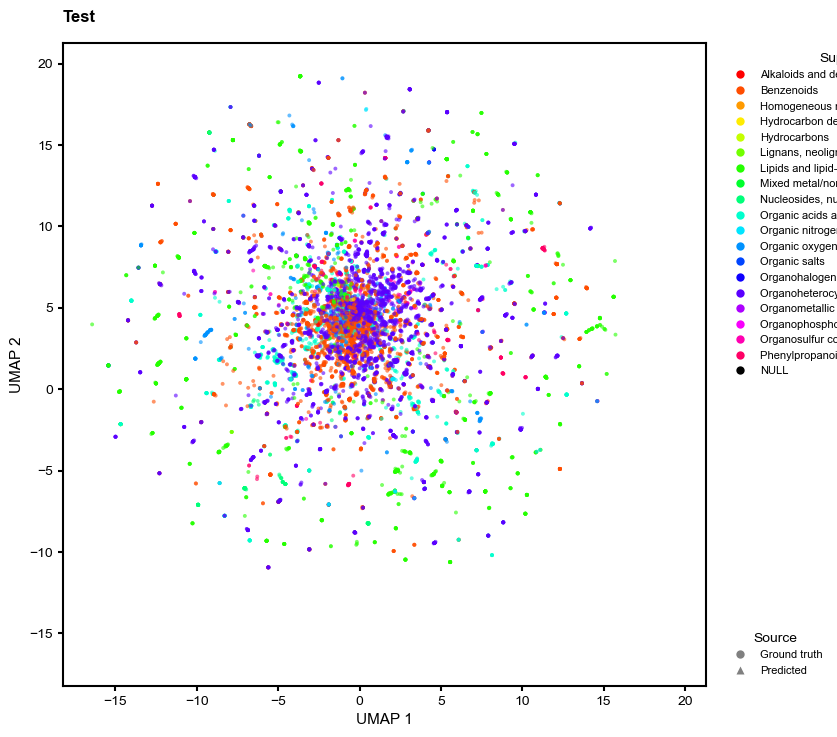

In [11]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=26).fit(X_train_scaled)
embedding_train = reducer.transform(X_train_scaled)
embedding_test = reducer.transform(X_test_scaled)

axis_min = min(embedding_train[:, 0].min(), embedding_train[:, 1].min(), embedding_test[:, 0].min(), embedding_test[:, 1].min())
axis_max = max(embedding_train[:, 0].max(), embedding_train[:, 1].max(), embedding_test[:, 0].max(), embedding_test[:, 1].max())

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
plot_chemical_space(ax, embedding_train, train_df["superclass"], category_to_color, "UMAP 1", "UMAP 2", axis_min, axis_max, title="Train")
plt.show()

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)
plot_chemical_space(ax, embedding_test, test_df["superclass"], category_to_color, "UMAP 1", "UMAP 2", axis_min, axis_max, title="Test")
plt.show()